# AI detection tools evaluation
## Dataset download

In [1]:
from datasets import load_dataset
ds = load_dataset("silentone0725/ai-human-text-detection-v1")

Repo card metadata block was not found. Setting CardData to empty.


In [ ]:
# ds.save_to_disk("ai_human_text_detection_data")

Saving the dataset (0/1 shards):   0%|          | 0/36744 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7874 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/7874 [00:00<?, ? examples/s]

In [ ]:
# data = ds["train"]

# TEXT_COL = "text"
# LABEL_COL = "label"

# ai_texts = []
# human_texts = []

# for item in data:

#     text = item[TEXT_COL].strip()
#     if not text:
#         continue
#     text = text.strip()
#     label = item[LABEL_COL]

#     if len(text.split()) < 50:
#         continue

#     if label == "ai" and len(ai_texts) < 25:
#         ai_texts.append(text)
#     elif label == "human" and len(human_texts) < 25:
#         human_texts.append(text)

#     if len(ai_texts) == 25 and len(human_texts) == 25:
#         break

# def save_to_file(texts, filename):
#     with open(filename, "w", encoding="utf-8") as f:
#         for i, text in enumerate(texts, start=1):
#             f.write(f"{i}\n{text}\n\n")

# save_to_file(ai_texts, "tools_test_data/ai_texts.txt")
# save_to_file(human_texts, "tools_test_data/human_texts.txt")

Above two cells were meant to be run only once in order to extract data from the dataset that will be used as input to the *GPTZero* detector.

## Models inference

In [2]:
from datasets import load_dataset
from transformers import pipeline, GPT2LMHeadModel, GPT2Tokenizer
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix
import torch
import numpy as np

In [3]:
data = ds["train"].shuffle(seed=42).select(range(200))

TEXT_COL = "text"
LABEL_COL = "label"

detector_base = pipeline(
    "text-classification",
    model="roberta-base-openai-detector",
    truncation=True
)

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: roberta-base-openai-detector
Key                         | Status     |  | 
----------------------------+------------+--+-
roberta.pooler.dense.bias   | UNEXPECTED |  | 
roberta.pooler.dense.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:180: UserWarning: CUDA initialization: The NVIDIA driver on your system is too old (found version 12020). Please update your GPU driver by downloading and installing a new version from the URL: http://www.nvidia.com/Download/index.aspx Alternatively, go to: https://pytorch.org to install a PyTorch version that has been compiled with your version of the CUDA driver. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:119.)
  return torch._C._cuda_getDeviceCount() > 0


In [4]:
y_true_roberta = []
y_pred_base_roberta = []

def map_label(pred_label):
    return 1 if pred_label == "Fake" else 0

for item in data:
    text = item[TEXT_COL]
    true_label = item[LABEL_COL]

    pred = detector_base(text)[0]
    pred_label = map_label(pred["label"])

    y_true_roberta.append(true_label)
    y_pred_base_roberta.append(pred_label)

In [5]:
tokenizer_gpt2 = GPT2Tokenizer.from_pretrained("gpt2")
model_gpt2 = GPT2LMHeadModel.from_pretrained("gpt2")
model_gpt2.eval()

def compute_perplexity(text):
    encodings = tokenizer_gpt2(text, return_tensors="pt", truncation=True, max_length=512)
    input_ids = encodings.input_ids

    with torch.no_grad():
        outputs = model_gpt2(input_ids, labels=input_ids)
        loss = outputs.loss

    return torch.exp(loss).item()

def perplexity_to_label(ppl, threshold=50):
    return 1 if ppl < threshold else 0

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

In [6]:
y_pred_ppl = []

for item in data:
    text = item["text"]
    true_label = item["label"]

    ppl = compute_perplexity(text)
    pred_ppl = perplexity_to_label(ppl)

    y_pred_ppl.append(pred_ppl)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


## Metrics
### RoBERTa

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix,
    classification_report
)

def evaluate(name, y_true, y_pred):
    print(classification_report(y_true, y_pred, labels=["human", "ai"]))

    cm = confusion_matrix(y_true, y_pred, labels=["human", "ai"])

    tn, fp, fn, tp = cm.ravel()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

    print(f"\nFalse Positive Rate (FPR): {fpr:.3f}")
    print(f"False Negative Rate (FNR): {fnr:.3f}")

    _, ax = plt.subplots()
    ax.imshow(cm)

    ax.set_xticks(np.arange(2))
    ax.set_yticks(np.arange(2))
    ax.set_xticklabels(["human", "ai"])
    ax.set_yticklabels(["human", "ai"])

    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix - {name}")

    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")

    plt.tight_layout()
    plt.show()

              precision    recall  f1-score   support

       human       0.90      0.95      0.93        86
          ai       0.96      0.92      0.94       114

    accuracy                           0.94       200
   macro avg       0.93      0.94      0.93       200
weighted avg       0.94      0.94      0.94       200


False Positive Rate (FPR): 0.047
False Negative Rate (FNR): 0.079


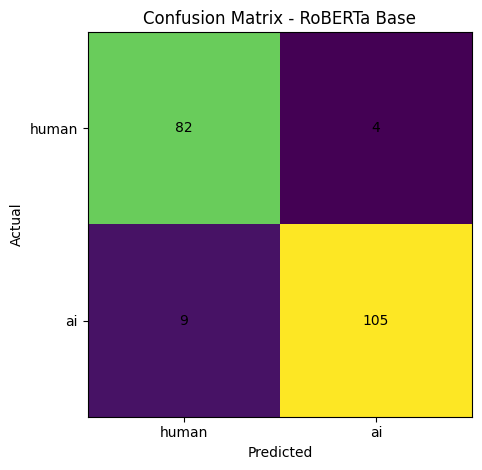

In [8]:
evaluate("RoBERTa Base", y_true_roberta, list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_base_roberta)))

### GPT2

              precision    recall  f1-score   support

       human       1.00      0.50      0.67        86
          ai       0.73      1.00      0.84       114

    accuracy                           0.79       200
   macro avg       0.86      0.75      0.75       200
weighted avg       0.84      0.79      0.77       200


False Positive Rate (FPR): 0.500
False Negative Rate (FNR): 0.000


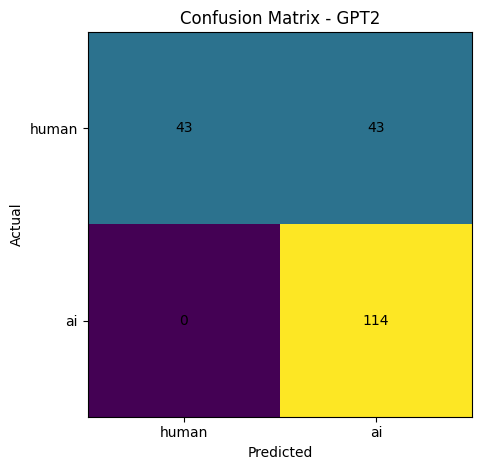

In [9]:
evaluate("GPT2", y_true_roberta, list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_ppl)))

### GPTZero

In [10]:
import re
import pandas as pd

def parse_file(path):
    with open(path, "r", encoding="utf-8") as f:
        content = f.read()

    entries = re.split(r'\n(?=\d+[.,])', content)

    rows = []

    for entry in entries[1:]:
        entry = entry.strip()
        if not entry:
            continue

        try:
            first_comma = entry.find(',')
            second_comma = entry.find(',', first_comma + 1)

            id_ = entry[:first_comma].strip()
            text_and_rest = entry[first_comma+1:]

            last_comma = text_and_rest.rfind(',')
            second_last_comma = text_and_rest.rfind(',', 0, last_comma)

            text = text_and_rest[:second_last_comma].strip().strip('"')
            label = text_and_rest[second_last_comma+1:last_comma].strip()
            score = text_and_rest[last_comma+1:].strip()

            rows.append({
                "id": int(id_),
                "text": text,
                "true_label": label,
                "score": float(score)
            })

        except Exception as e:
            print(f"Skipping malformed entry:\n{entry[:100]}...\nError: {e}\n")

    return pd.DataFrame(rows)


df = parse_file("results/gprzero.csv")

print(df.head())
print(f"Loaded rows: {len(df)}")

   id                                               text true_label  score
0   1  We don't actually know what color dinosaurs li...         ai   0.00
1   2  A ship of the line was a type of warship that ...         ai   1.00
2   3  There are many complex factors that have contr...         ai   0.38
3   4  Elijah McCoy (1844-1929) was an African Americ...         ai   0.81
4   5  It's true that China is a major player in the ...         ai   0.05
Loaded rows: 30


              precision    recall  f1-score   support

       human       0.75      1.00      0.86        15
          ai       1.00      0.67      0.80        15

    accuracy                           0.83        30
   macro avg       0.88      0.83      0.83        30
weighted avg       0.88      0.83      0.83        30


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.333


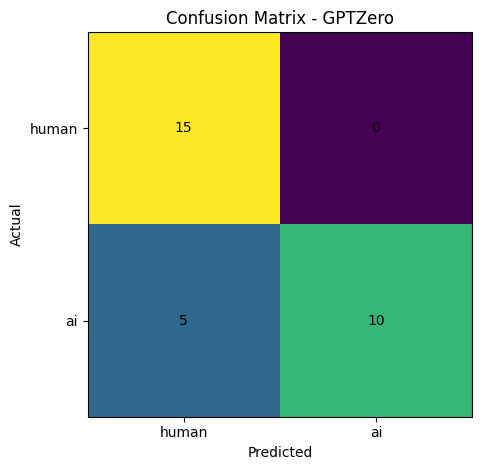

In [11]:
df["pred_label"] = df["score"].apply(lambda x: "ai" if x >= 0.5 else "human")

y_true_gpt = df["true_label"]
y_pred_gpt = df["pred_label"]

evaluate("GPTZero", y_true_gpt, y_pred_gpt)

### Prompt and paraphrasing effect analysis

Firstly let's look on the efficiency of the ai generated text detection, when we prompt the model to generate undetectable text.

In [ ]:
new_generated_texts = [
    "I remember missing the last tram home on a rainy evening and deciding to walk instead. The streets were nearly empty, just the occasional flicker of light from apartment windows. Somewhere along the way, the rain eased, and the city felt quieter than usual, almost suspended. It wasn’t a remarkable night by any standard, but I still think about it sometimes, how unplanned moments can feel more complete than carefully arranged ones.",
    "There’s something oddly satisfying about fixing small things around the house. It’s rarely about saving money or even necessity. More often, it’s the process: figuring out why a drawer sticks or why a hinge squeaks. You try something, fail, try again. Eventually it works, and the result is subtle but noticeable. No one else might care, but you know it’s better than before, and that’s enough.",
    "When people talk about productivity, they often focus on tools or routines, but I’ve found that timing matters more than anything else. Some days, even simple tasks feel heavy, while on others, complex work flows naturally. I’ve stopped forcing it as much. Instead, I try to notice when my attention is actually there and use that window well, even if it doesn’t align perfectly with a schedule.",
    "I once spent an afternoon in a small café where nothing particularly interesting happened. A few people came and went, someone read a newspaper, and the music changed every so often. Still, it felt like time slowed down just enough to notice details—the way cups were stacked, the rhythm of footsteps, the quiet pauses between conversations. It made me realize how much usually goes unnoticed.",
    "Learning something new as an adult feels different than it did years ago. There’s less pressure to prove anything, but also less patience for confusion. You notice gaps more clearly. At the same time, there’s a kind of freedom in approaching things without expectations. Progress may be slower, but it feels more deliberate, like you’re choosing each step rather than being pushed along.",
    "Cooking has become a small daily routine that I didn’t expect to enjoy as much as I do. At first it was just a practical necessity, but over time I started paying attention to small details: how ingredients change with heat, how timing affects texture, how simple combinations can produce different results. It’s not about making elaborate meals. Even basic dishes feel more satisfying when there is some intention behind them.",
    "Public transport gives you a particular kind of perspective on a city. You see patterns that aren’t obvious when moving quickly: where people get on and off, how neighborhoods change gradually, how routines overlap. I often find myself observing rather than thinking about my destination. The journey becomes a sequence of small observations instead of a transition to somewhere else. It changes how time feels during the trip.",
    "I’ve been trying to spend less time switching between tasks during the day. It’s easy to underestimate how much energy that consumes. When I focus on one thing for longer, even if it seems slower at first, the result is usually better. There’s less need to revisit and correct mistakes. It’s a simple adjustment, but it requires resisting the impulse to check something else every few minutes.",
    "Weather has a subtle influence on how I structure my day. On colder days I tend to stay indoors and focus on quieter activities, while warmer days make it easier to go outside without much planning. It’s not a strict rule, but more of a tendency that shapes decisions without conscious effort. Paying attention to these patterns helps me understand why some days feel more productive or relaxed than others.",
    "Over time I’ve become more aware of how small changes accumulate. Adjusting a routine slightly, rearranging a workspace, or changing how I start the morning can have a noticeable effect after a few weeks. None of these changes are dramatic on their own, but together they shift how the day unfolds. It’s a gradual process, easy to overlook unless you step back and compare it with how things used to be."
]

y_pred_new_roberta = []
y_pred_new_ppl = []

for text in new_generated_texts:
    pred = detector_base(text)[0]
    pred_label = map_label(pred["label"])
    y_pred_new_roberta.append(pred_label)

    ppl = compute_perplexity(text)
    pred_ppl = perplexity_to_label(ppl)
    y_pred_new_ppl.append(pred_ppl)

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.10      0.18        10

    accuracy                           0.10        10
   macro avg       0.50      0.05      0.09        10
weighted avg       1.00      0.10      0.18        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.900


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

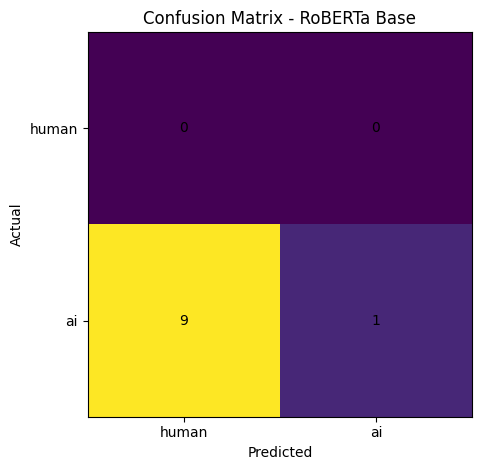

In [17]:
evaluate("RoBERTa Base", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_roberta)))

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.80      0.89        10

    accuracy                           0.80        10
   macro avg       0.50      0.40      0.44        10
weighted avg       1.00      0.80      0.89        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.200


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

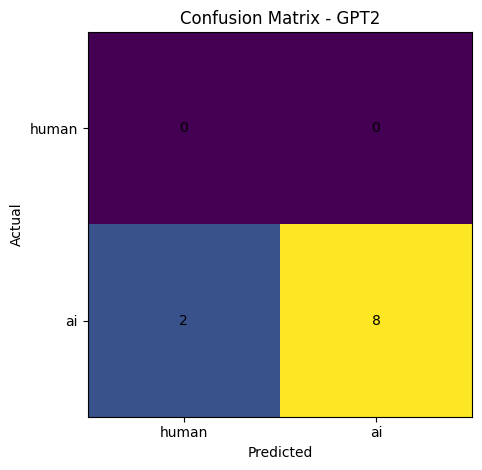

In [18]:
evaluate("GPT2", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_ppl)))

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       0.50      0.50      0.50        10
weighted avg       1.00      1.00      1.00        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.000


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to contro

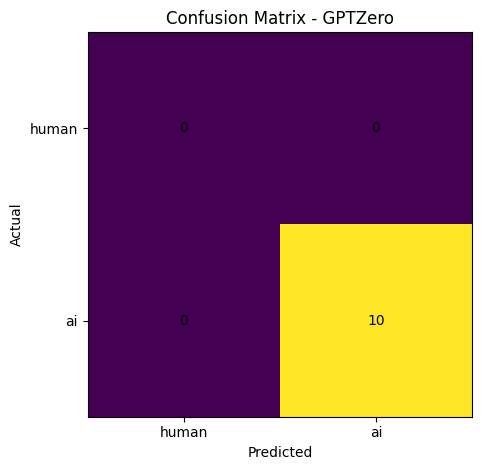

In [20]:
evaluate("GPTZero", ["ai"] * len(new_generated_texts), ["ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai"])

Now let's remove ’ signs typical to *ChatGPT*

In [21]:
new_generated_texts = [
    "I remember missing the last tram home on a rainy evening and deciding to walk instead. The streets were nearly empty, just the occasional flicker of light from apartment windows. Somewhere along the way, the rain eased, and the city felt quieter than usual, almost suspended. It wasn't a remarkable night by any standard, but I still think about it sometimes, how unplanned moments can feel more complete than carefully arranged ones.",
    "There's something oddly satisfying about fixing small things around the house. It's rarely about saving money or even necessity. More often, it's the process: figuring out why a drawer sticks or why a hinge squeaks. You try something, fail, try again. Eventually it works, and the result is subtle but noticeable. No one else might care, but you know it's better than before, and that's enough.",
    "When people talk about productivity, they often focus on tools or routines, but I've found that timing matters more than anything else. Some days, even simple tasks feel heavy, while on others, complex work flows naturally. I've stopped forcing it as much. Instead, I try to notice when my attention is actually there and use that window well, even if it doesn't align perfectly with a schedule.",
    "I once spent an afternoon in a small café where nothing particularly interesting happened. A few people came and went, someone read a newspaper, and the music changed every so often. Still, it felt like time slowed down just enough to notice details—the way cups were stacked, the rhythm of footsteps, the quiet pauses between conversations. It made me realize how much usually goes unnoticed.",
    "Learning something new as an adult feels different than it did years ago. There's less pressure to prove anything, but also less patience for confusion. You notice gaps more clearly. At the same time, there's a kind of freedom in approaching things without expectations. Progress may be slower, but it feels more deliberate, like you're choosing each step rather than being pushed along.",
    "Cooking has become a small daily routine that I didn't expect to enjoy as much as I do. At first it was just a practical necessity, but over time I started paying attention to small details: how ingredients change with heat, how timing affects texture, how simple combinations can produce different results. It's not about making elaborate meals. Even basic dishes feel more satisfying when there is some intention behind them.",
    "Public transport gives you a particular kind of perspective on a city. You see patterns that aren't obvious when moving quickly: where people get on and off, how neighborhoods change gradually, how routines overlap. I often find myself observing rather than thinking about my destination. The journey becomes a sequence of small observations instead of a transition to somewhere else. It changes how time feels during the trip.",
    "I've been trying to spend less time switching between tasks during the day. It's easy to underestimate how much energy that consumes. When I focus on one thing for longer, even if it seems slower at first, the result is usually better. There's less need to revisit and correct mistakes. It's a simple adjustment, but it requires resisting the impulse to check something else every few minutes.",
    "Weather has a subtle influence on how I structure my day. On colder days I tend to stay indoors and focus on quieter activities, while warmer days make it easier to go outside without much planning. It's not a strict rule, but more of a tendency that shapes decisions without conscious effort. Paying attention to these patterns helps me understand why some days feel more productive or relaxed than others.",
    "Over time I've become more aware of how small changes accumulate. Adjusting a routine slightly, rearranging a workspace, or changing how I start the morning can have a noticeable effect after a few weeks. None of these changes are dramatic on their own, but together they shift how the day unfolds. It's a gradual process, easy to overlook unless you step back and compare it with how things used to be."
]

y_pred_new_roberta = []
y_pred_new_ppl = []

for text in new_generated_texts:
    pred = detector_base(text)[0]
    pred_label = map_label(pred["label"])
    y_pred_new_roberta.append(pred_label)

    ppl = compute_perplexity(text)
    pred_ppl = perplexity_to_label(ppl)
    y_pred_new_ppl.append(pred_ppl)

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.10      0.18        10

    accuracy                           0.10        10
   macro avg       0.50      0.05      0.09        10
weighted avg       1.00      0.10      0.18        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.900


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

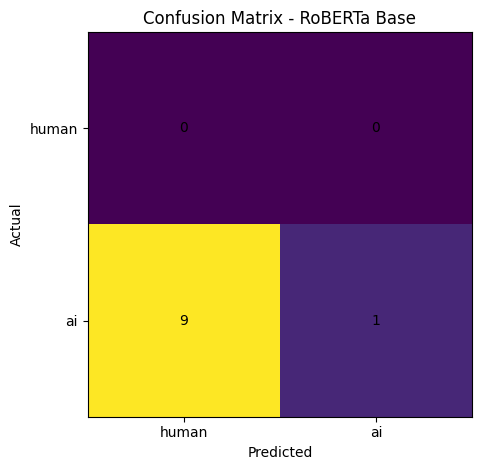

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.90      0.95        10

    accuracy                           0.90        10
   macro avg       0.50      0.45      0.47        10
weighted avg       1.00      0.90      0.95        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.100


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

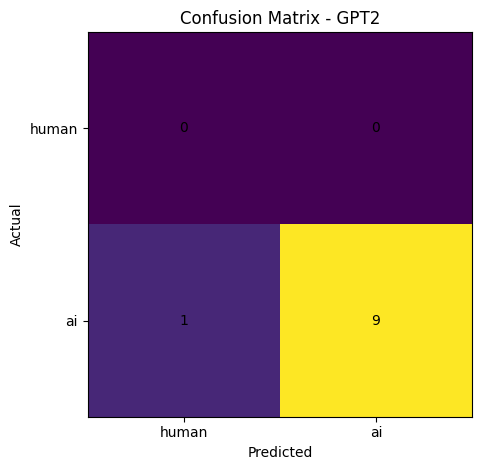

/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to contro

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       0.50      0.50      0.50        10
weighted avg       1.00      1.00      1.00        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.000


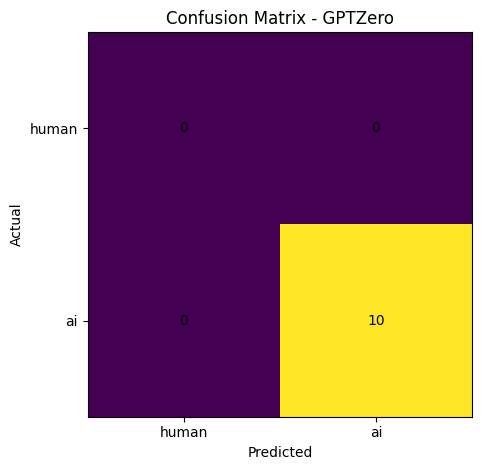

In [23]:
evaluate("RoBERTa Base", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_roberta)))
evaluate("GPT2", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_ppl)))
evaluate("GPTZero", ["ai"] * len(new_generated_texts), ["ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai"])

Now let's ask *ChatGPT* to paraphrase those sentences to appear more human like.

In [24]:
new_generated_texts = [
    "I remember missing the last tram one evening when it was raining and just deciding to walk home instead. The streets were almost empty, with only a few lights on in the windows. At some point the rain stopped, and everything felt unusually quiet, like the city had slowed down for a bit. Nothing special really happened, but for some reason I still think about that night. It had a kind of completeness you don’t usually get when things are planned.",
    "There’s something strangely satisfying about fixing small things at home. It’s not really about saving money most of the time. It’s more about figuring things out—why a drawer keeps sticking or what’s causing that annoying squeak. You try one thing, then another, sometimes it doesn’t work. But when it finally does, even if it’s something minor, it feels worth it. No one else notices, but you do.",
    "When people talk about productivity, they usually focus on tools or habits, but for me timing seems to matter more. Some days even simple things feel difficult, and other days more complex work just flows. I’ve stopped trying to force it as much. Now I try to pay attention to when I can actually focus and make use of that, even if it doesn’t fit neatly into a schedule.",
    "I once spent a few hours in a small café where nothing particularly interesting happened. People came in, ordered, left. Someone sat reading a newspaper. The music kept changing quietly in the background. Still, it felt like everything slowed down just enough to notice small details—the way cups were arranged, how people moved, those brief pauses in conversation. It made me realize how much I usually overlook.",
    "Learning something new as an adult feels noticeably different than it used to. There’s less pressure, which is nice, but also less patience when things don’t make sense right away. You’re more aware of what you don’t know. At the same time, there’s a kind of freedom in it—you can approach things without expectations. Progress might be slower, but it feels more intentional.",
    "Cooking has turned into a small routine I didn’t expect to enjoy this much. It started out as something practical, but over time I began paying attention to details—how heat changes ingredients, how timing affects texture, how simple combinations can turn out differently. I’m not making anything complicated. But even basic meals feel more satisfying when there’s some thought behind them.",
    "Using public transport gives you a different way of seeing a city. You start noticing patterns—where people get on and off, how areas gradually change, how routines overlap. I often catch myself just observing instead of thinking about where I’m going. The trip becomes a series of small moments rather than just getting from one place to another. It changes how time feels.",
    "Lately I’ve been trying not to switch between tasks so much during the day. It’s easy to underestimate how draining that is. When I stay focused on one thing longer, even if it feels slower at first, the results are usually better. There’s less going back to fix things. It’s a simple change, but it takes some effort to ignore the urge to check something else all the time.",
    "Weather seems to influence my day more than I used to notice. When it’s cold, I tend to stay inside and do quieter things. When it’s warmer, going out feels more natural, even without planning it. It’s not something I decide consciously—it just happens. Paying attention to it helps explain why some days feel more productive or more relaxed than others.",
    "Over time I’ve started noticing how small changes add up. Slight adjustments to a routine, moving things around in a workspace, even changing how the day starts—after a while, it all makes a difference. None of it feels dramatic in the moment, but together it shifts how things work. You only really see it when you compare it to how things used to be."
]

y_pred_new_roberta = []
y_pred_new_ppl = []

for text in new_generated_texts:
    pred = detector_base(text)[0]
    pred_label = map_label(pred["label"])
    y_pred_new_roberta.append(pred_label)

    ppl = compute_perplexity(text)
    pred_ppl = perplexity_to_label(ppl)
    y_pred_new_ppl.append(pred_ppl)

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.10      0.18        10

    accuracy                           0.10        10
   macro avg       0.50      0.05      0.09        10
weighted avg       1.00      0.10      0.18        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.900


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

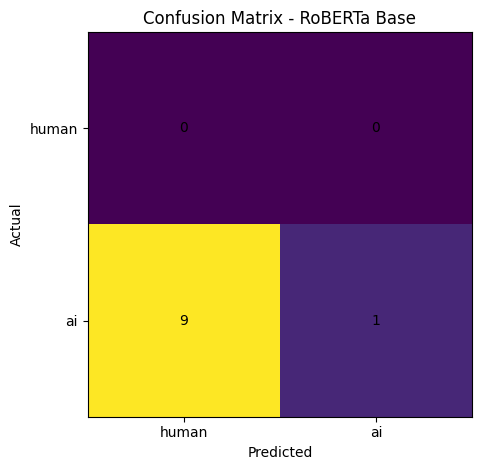

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.90      0.95        10

    accuracy                           0.90        10
   macro avg       0.50      0.45      0.47        10
weighted avg       1.00      0.90      0.95        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.100


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

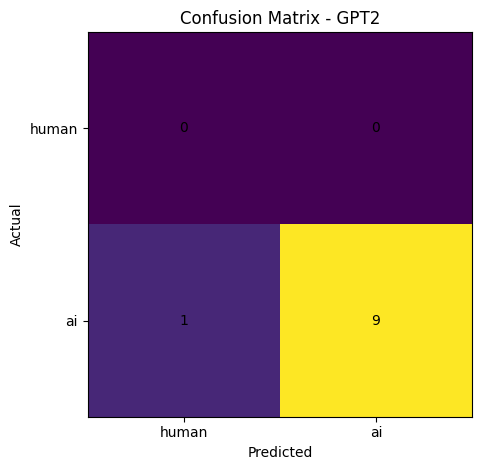

/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to contro

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       0.50      0.50      0.50        10
weighted avg       1.00      1.00      1.00        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.000


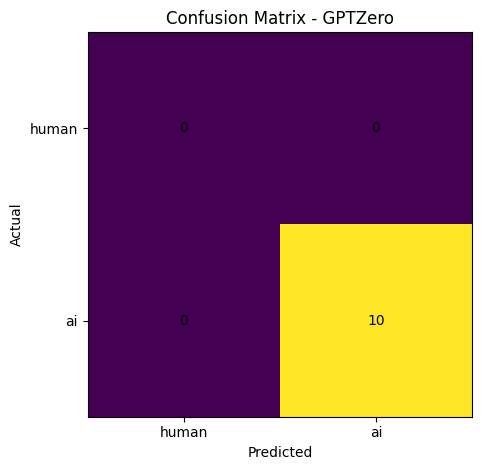

In [25]:
evaluate("RoBERTa Base", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_roberta)))
evaluate("GPT2", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_ppl)))
evaluate("GPTZero", ["ai"] * len(new_generated_texts), ["ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai"])

Another 10 sentences, this time asking *ChatGPT* to write like a 1st year student without sophisticated words and in simple language.

In [26]:
new_generated_texts = [
    "I think that studying at university is very different from high school. First of all, there is more freedom, but also more responsibility. Students need to manage their own time and decide when to study. Sometimes it is hard because there are many distractions, like social media or meeting friends. I also noticed that lectures are bigger, and it is easier to feel lost. However, I like that I can choose some subjects. It makes learning more interesting and personal. I believe that with good organization, it is possible to succeed.",
    "Living away from home for the first time is not easy. At the beginning, I felt a bit lonely and confused. I had to learn how to cook, clean, and take care of myself. These things may seem simple, but they take time and effort. On the other hand, it is also exciting because I can make my own decisions. I can decide what to eat and how to spend my free time. I think this experience helps me grow as a person and become more independent.",
    "In my opinion, making new friends at university is very important. When you know people, everything becomes easier and more enjoyable. At first, I was shy and did not talk much, but later I started joining group activities. This helped me meet others who have similar interests. Now I have a few good friends that I can study with or just relax. It is nice to have someone to talk to when things are difficult. I think friendships are a big part of student life.",
    "Sometimes studying can be stressful, especially during exams. There is a lot of material to remember, and not much time. I try to make a study plan, but it does not always work. I often feel tired and lose motivation. To deal with stress, I take short breaks and go for a walk. Listening to music also helps me relax. I think it is important not to study all the time, because rest is also needed. Balance is the key to doing well.",
    "Online learning has become more common in recent years. It has some advantages, like being able to study from home. This saves time and money, especially for students who live far away. However, it is also harder to stay focused during online classes. There are many distractions at home, and sometimes the internet connection is not good. I think that a mix of online and in-person classes would be the best solution. This way, students can get the benefits of both.",
    "Time management is one of the most important skills for students. Without it, it is easy to fall behind. I try to use a calendar to keep track of my tasks and deadlines. Still, I sometimes leave things until the last moment. This causes stress and affects my work quality. I am trying to improve by starting earlier and breaking tasks into smaller parts. I think that with practice, I will get better at managing my time.",
    "Group projects can be both good and bad. On one hand, they allow students to share ideas and learn from each other. On the other hand, not everyone works the same way. Sometimes one person does most of the work, while others do very little. This can be frustrating. I think communication is very important in group work. If everyone is clear about their tasks, the project can go more smoothly. In general, I prefer small groups.",
    "I believe that part-time jobs can be helpful for students. They provide extra money and also teach responsibility. I started working a few hours a week, and it helped me understand the value of time. However, it can be difficult to balance work and study. Sometimes I feel too tired to focus on my classes. I think it is important not to work too much and to remember that studying should come first.",
    "Technology plays a big role in education today. We use laptops, tablets, and online platforms almost every day. It makes learning easier in many ways. For example, we can quickly find information or watch videos to understand topics better. But there are also disadvantages. It is easy to get distracted by social media or games. I think students need to learn how to use technology in a smart way, not just for entertainment.",
    "Choosing a field of study is not always simple. Many students are not sure what they want to do in the future. I also had this problem when I started university. I chose my major because I found it interesting, but I am still thinking about my career. I believe it is normal to feel unsure at this stage. With time and experience, I hope to understand what I really want. It is important to stay open and try new things."
]

y_pred_new_roberta = []
y_pred_new_ppl = []

for text in new_generated_texts:
    pred = detector_base(text)[0]
    pred_label = map_label(pred["label"])
    y_pred_new_roberta.append(pred_label)

    ppl = compute_perplexity(text)
    pred_ppl = perplexity_to_label(ppl)
    y_pred_new_ppl.append(pred_ppl)

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      0.70      0.82        10

    accuracy                           0.70        10
   macro avg       0.50      0.35      0.41        10
weighted avg       1.00      0.70      0.82        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.300


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _war

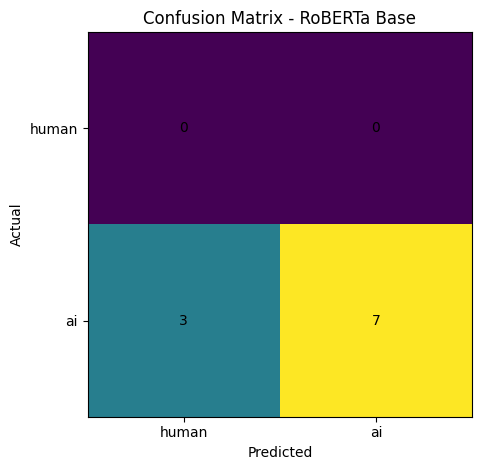

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       0.50      0.50      0.50        10
weighted avg       1.00      1.00      1.00        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.000


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to contro

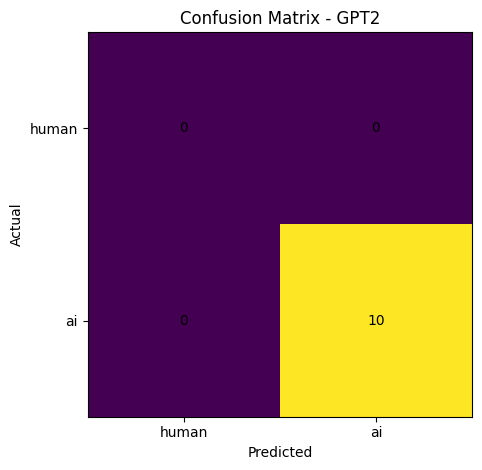

              precision    recall  f1-score   support

       human       0.00      0.00      0.00         0
          ai       1.00      1.00      1.00        10

    accuracy                           1.00        10
   macro avg       0.50      0.50      0.50        10
weighted avg       1.00      1.00      1.00        10


False Positive Rate (FPR): 0.000
False Negative Rate (FNR): 0.000


/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/drzewo/szt_mag/ai_generated_data_detection/.venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to contro

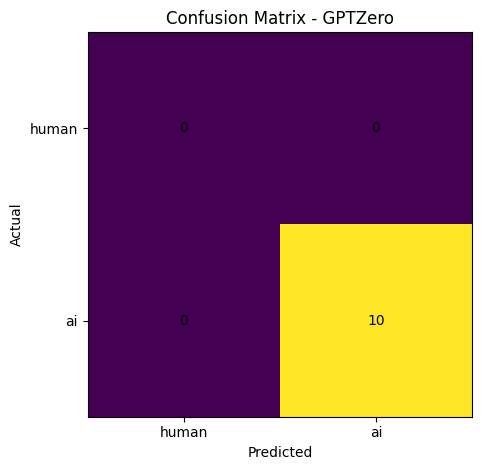

In [27]:
evaluate("RoBERTa Base", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_roberta)))
evaluate("GPT2", ["ai"] * len(new_generated_texts), list(map(lambda x: 'human' if x == 0 else 'ai', y_pred_new_ppl)))
evaluate("GPTZero", ["ai"] * len(new_generated_texts), ["ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai", "ai"])